In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Handwritten Digit Classification (Digits 8×8)
Algorithm       : Vanilla Recurrent Neural Network (RNN) – completely from scratch

Description     : Full manual implementation of a simple (Vanilla) RNN 
                  without using any high-level recurrent layers (nn.RNN, etc.).

                  Implemented components from scratch:
                  - Input-to-hidden and hidden-to-hidden weight matrices
                  - Forward propagation through time
                  - Backpropagation Through Time (BPTT)
                  - Softmax output for multi-class classification

                  The 8×8 digit images are treated as sequences of length 8 
                  with 8 features per time step.

                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#%% load dataset 
ds= load_digits()
data= ds['data']
target= ds['target']
print(data.shape,target.shape)

(1797, 64) (1797,)


In [3]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=True)

In [4]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [5]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain).type(torch.float32).unsqueeze(2)
y_train= torch.from_numpy(y_train).type(torch.float32)
y_train_onhot=(y_train.reshape(-1,1)==
               torch.arange(10).reshape(1,-1)).type(torch.float32)



Xtest= torch.from_numpy(Xtest).type(torch.float32).unsqueeze(2)
y_test= torch.from_numpy(y_test).type(torch.float32)
y_test_onhot=(y_test.reshape(-1,1)==torch.arange(10).reshape(1,-1)).type(torch.float32)

In [6]:
class Customdataset(Dataset):
    def __init__(self,data,label):
        super().__init__()
        self.data= data
        self.label= label
    def __len__(self):
        return self.label.shape[0]
    def __getitem__(self, index):
        x= self.data[index]
        y= self.label[index]
        
        x= x.reshape(8,8)
        # x= x.permute(1,0)
        return x,y
        

In [7]:
#% build data loader 
# ds= TensorDataset(Xtrain,y_train_onhot)
ds= Customdataset(Xtrain,y_train_onhot)
train_loader= DataLoader(ds,batch_size=4,
                         shuffle=False,
                         drop_last=True)

In [8]:
class RNN():
     def __init__(self,n_features,n_hidden,n_out,lr=0.001,wrate=1):
          self.n_features= n_features
          self.n_hidden= n_hidden
          self.n_out= n_out
          self.lr=lr
          
          self.wx= torch.randn(n_hidden,n_features)*wrate
          self.bx= torch.randn(n_hidden,1)*wrate
          
          self.whh= torch.randn(n_hidden,n_hidden)*wrate
          
          self.wo= torch.randn(n_out,n_hidden)*wrate
          self.bo= torch.randn(n_out,1)*wrate
          
          
          self.dwx= torch.zeros_like(self.wx)
          self.dbx= torch.zeros_like(self.bx)
          self.dwhh= torch.zeros_like(self.whh)
          self.dwo= torch.zeros_like(self.wo)
          self.dbo= torch.zeros_like(self.bo)   
          
     def __call__(self,x,h0=None):
          yos,hts,hps= self.forward(x,h0)
          return yos,hts,hps
            
     def forward(self,x,h0=None):  
          wx,bx,whh,wo,bo= self.wx,self.bx,self.whh,self.wo,self.bo
          bath_size,T,_= x.size()# b_s x T x n_f (4,5,12)
          n_hidden,n_out= self.n_hidden,self.n_out
          
          if h0 == None:
               h_prev= torch.zeros(n_hidden,bath_size)
          else:
               h_prev= h0
          
          yos=[]
          hts=[]
          hps=[]
          
          for t in range(T):
               xt= x[:,t,:].T # (b_s x n_f).T = n_f x b_s
               vt= wx@xt + whh@h_prev + bx # n_hid x n_f,  n_f x b_s = n_hid*b_s
               ht= torch.tanh(vt) # n_hid*b_s

               hts.append(ht)
               hps.append(h_prev)
               h_prev= ht # n_hid*b_s
               
          vot= wo@ht + bo # n_o x n_hid x n_hid x b_s = n_o x b_s
          yt= torch.softmax(vot,dim=0)
          yos.append(yt)
          return yos,hts,hps
   
     def backward(self,x,y_true, y_pred,hts,hps):
          wx,bx,whh,wo,bo= self.wx,self.bx,self.whh,self.wo,self.bo
          bath_size,T,_= x.size()# b_s x T x n_f (4,5,12)
          n_hidden,n_out= self.n_hidden,self.n_out

          yot= y_pred[-1]
          dt= y_true.T #  n_out x b_s 
          
          # et= dt-yot
          delta_o= dt-yot # n_o x b_s
          self.dwo=delta_o@ hts[-1].T# n_o x b_s x b_s x n_hid = n_o x n_hid
          self.dbo= torch.sum(delta_o,dim=1,keepdim=True)
          
          dh_next= torch.zeros(bath_size,n_hidden)
          for t in reversed(range(T)):
               xt= x[:,t,:] # b_s*n_f
               ht= hts[t].T# (n_hid*b_s).T= b_s x n_hid
               h_prev= hps[t].T# (n_hid*b_s).T= b_s x n_hid
               dh_out= delta_o.T@ wo # b_s x n_o x n_o x n_hid = b_s x n_hid
               gdh= self.g_tanh(ht)# b_s x n_hid
               # dv=#
               # dh= dh_out + dh_next # b_s x n_hid
               if t==T-1:
                    dh= dh_out # n_hid x b_s
               else:
                    dh= dh_next
               
               dv= (dh*gdh).T

               self.dwx+= dv@xt #n_hid x b_s x b_s*n_f = n_hid x n_f
               self.dbx+= torch.sum(dv,dim=1,keepdim=True)
               
               self.dwhh+= dv@h_prev # n_hid x b_s x b_s x n_hid
               
               dh_next= (dv.T@whh) #( n_hid x b_s).T= (b_s x n_hid )
          
          # self.dwx/= (bath_size)
          # self.dbx/= (bath_size)
          # self.dwhh/= (bath_size)
          # self.dwo/= (bath_size)
          # self.dbo/= (bath_size)
               
     def step(self):
          self.wx+=self.lr*self.dwx
          self.bx+=self.lr*self.dbx
          self.whh+=self.lr*self.dwhh
          self.wo+=self.lr*self.dwo
          self.bo+=self.lr*self.dbo
     
     def zero_grad(self):
          self.dwx.zero_()
          self.dbx.zero_()
          self.dwhh.zero_()
          self.dwo.zero_()
          self.dbo.zero_() 
     
     def mse(self,y_true,y_pred):
          y_true= y_true.T
          e= y_true-y_pred
          return torch.mean(e**2)
     
     def g_tanh(self,y):
          return (1-y**2)
     
     def g_sigmoid(self,y):
          return y*(1-y)
     
     def g_relu(self,y):
          yhat= (y>0).type(torch.float32)
          return yhat
     
     def g_linear(self,y):
          return torch.ones(y.size())

In [9]:
#%% train Neural Network
torch.manual_seed(1)
lr=0.01
n_out= 10
n_hid1= 85

n_features=8
mdl= RNN(n_features, 
         n_hid1,
         n_out,
         lr,wrate=0.01)

In [10]:
mse=[]
epoch=20
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred,hts,hps= mdl(xbatch)
          mdl.zero_grad()
          mdl.backward(xbatch,ybatch,ypred,hts,hps) 
          mdl.step()
          er.append(mdl.mse(ybatch,ypred[-1])) 
          # print(er[i])

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter}): {mse[iter]:.8f}')

mse=torch.tensor(mse)


MSE(0): 0.08538231
MSE(1): 0.05919451
MSE(2): 0.03936228
MSE(3): 0.02300645
MSE(4): 0.01598774
MSE(5): 0.01201929
MSE(6): 0.00831662
MSE(7): 0.00576491
MSE(8): 0.00370451
MSE(9): 0.00251679
MSE(10): 0.00171636
MSE(11): 0.00111518
MSE(12): 0.00056509
MSE(13): 0.00032627
MSE(14): 0.00020403
MSE(15): 0.00013359
MSE(16): 0.00009147
MSE(17): 0.00006429
MSE(18): 0.00004674
MSE(19): 0.00003545


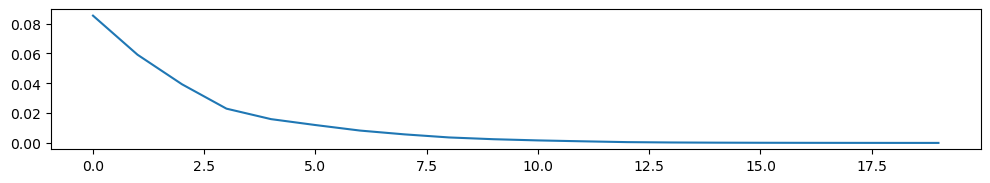

In [17]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

In [12]:
#%% test trained Neural Network
ds_test= Customdataset(Xtest,y_test)
ypred=[]
h0=None
for i in range(Xtest.size(0)):
    xt= ds_test[i][0]
    xt= xt.unsqueeze(0)
    yp= mdl(xt)[0]
    yp= torch.argmax(yp[-1].T,dim=1)
    ypred.append(yp)

ypred= np.array(ypred)

In [13]:
ypred=ypred.flatten()
d_test= y_test.flatten()

print(ypred.shape,d_test.shape,Xtest.shape,yp[-1].shape,Xtest[i].shape)

(540,) torch.Size([540]) torch.Size([540, 64, 1]) torch.Size([]) torch.Size([64, 1])


Total accuracy:96.111%
accuracy0:95.556%
accuracy1:98.113%
accuracy2:97.917%
accuracy3:92.308%
accuracy4:96.667%
accuracy5:92.188%
accuracy6:100.000%
accuracy7:100.000%
accuracy8:89.130%
accuracy9:98.148%


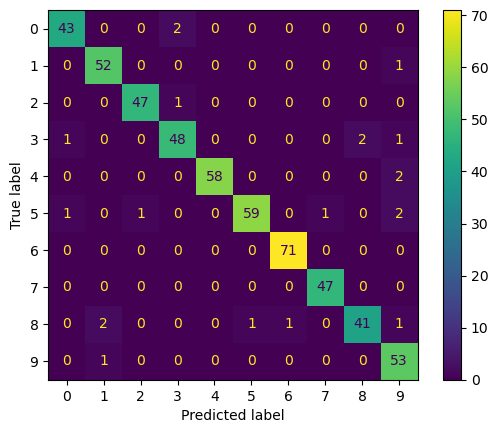

In [14]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(d_test,ypred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()